In [1]:
# UTKFace - Nationality Classifier

In [2]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [ ]:
# 1. Load UTKFace Images
data_path = "../data/UTKFace"

images = []
labels = []

max_images = 20000
count = 0

for file in os.listdir(data_path):
    if file.endswith(".jpg") and count < max_images:
        try:
            parts = file.split("_")
            if len(parts) < 3:
                continue

            ethnicity = int(parts[2])
            if ethnicity not in [0, 1, 2]:
                ethnicity = 3

            img_path = os.path.join(data_path, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))  # or (64, 64)
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(ethnicity)
            count += 1

        except Exception as e:
            print(f"Skipping {file}: {e}")

X = np.array(images, dtype=np.float32)
y = tf.keras.utils.to_categorical(np.array(labels), num_classes=4)



In [5]:
# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
# 3. CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50)


Epoch 1/10
250/250 [==============================] - 49s 194ms/step - loss: 1.0146 - accuracy: 0.5765 - val_loss: 0.7459 - val_accuracy: 0.7155
Epoch 2/10
250/250 [==============================] - 47s 189ms/step - loss: 0.7307 - accuracy: 0.7212 - val_loss: 0.8036 - val_accuracy: 0.6915
Epoch 3/10
250/250 [==============================] - 46s 184ms/step - loss: 0.6144 - accuracy: 0.7690 - val_loss: 0.6834 - val_accuracy: 0.7440
Epoch 4/10
250/250 [==============================] - 46s 186ms/step - loss: 0.5298 - accuracy: 0.7995 - val_loss: 0.7163 - val_accuracy: 0.7515
Epoch 5/10
250/250 [==============================] - 40s 162ms/step - loss: 0.4406 - accuracy: 0.8386 - val_loss: 0.7062 - val_accuracy: 0.7515
Epoch 6/10
250/250 [==============================] - 40s 160ms/step - loss: 0.3480 - accuracy: 0.8748 - val_loss: 0.7428 - val_accuracy: 0.7500
Epoch 7/10
250/250 [==============================] - 40s 158ms/step - loss: 0.2661 - accuracy: 0.9055 - val_loss: 0.8869 - val_ac

63/63 [==============================] - 2s 34ms/step
              precision    recall  f1-score   support

           0       0.74      0.67      0.70       628
           1       0.81      0.77      0.79       430
           2       0.89      0.76      0.82       377
           3       0.62      0.76      0.68       565

    accuracy                           0.74      2000
   macro avg       0.76      0.74      0.75      2000
weighted avg       0.75      0.74      0.74      2000



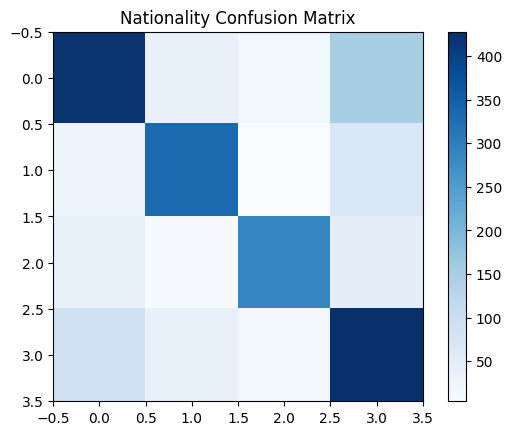

In [8]:
# 4. Evaluate
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Nationality Confusion Matrix")
plt.colorbar()
plt.savefig("../evaluation_metrics/nationality_confusion_matrix.png")
plt.show()

In [9]:
# 5. Save Model
model.save("../models/nationality_model.h5")

c:\Users\RITWIKA\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
